In [ ]:
!pip install -q numpy torch torchvision diffusers==0.29.2 transformers==4.36.0 peft==0.7.0 accelerate insightface onnxruntime-gpu gdown


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.8/126.8 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 57.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 58.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.3/168.3 kB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 762.2/762.2 kB 61.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 277.0/277.0 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 34.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 114.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 97.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 97.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.5.1 req

In [ ]:
!git clone -q https://github.com/foivospar/Arc2Face
import sys
sys.path.insert(0, "./Arc2Face")

In [ ]:
import torch
import numpy as np
from PIL import Image

from huggingface_hub import hf_hub_download

from diffusers import (
    StableDiffusionPipeline,
    UNet2DConditionModel,
    DPMSolverMultistepScheduler,
)

from arc2face import (
    CLIPTextModelWrapper,
    project_face_embs,
)

from insightface.app import FaceAnalysis


# ============================================================
# CONFIG
# ============================================================


SEED = 42
NUM_IMAGES = 1
NUM_STEPS = 25
GUIDANCE_SCALE = 3.0

if torch.cuda.is_available():
    DEVICE = "cuda"
    DTYPE = torch.float16
else:
    DEVICE = "cpu"
    DTYPE = torch.float32



/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(


In [ ]:

# ============================================================
# DOWNLOAD MODELS
# ============================================================

print("Downloading Arc2Face models...")

hf_hub_download(
    repo_id="FoivosPar/Arc2Face",
    filename="arc2face/config.json",
    local_dir="./models",
)

hf_hub_download(
    repo_id="FoivosPar/Arc2Face",
    filename="arc2face/diffusion_pytorch_model.safetensors",
    local_dir="./models",
)

hf_hub_download(
    repo_id="FoivosPar/Arc2Face",
    filename="encoder/config.json",
    local_dir="./models",
)

hf_hub_download(
    repo_id="FoivosPar/Arc2Face",
    filename="encoder/pytorch_model.bin",
    local_dir="./models",
)

hf_hub_download(
    repo_id="FoivosPar/Arc2Face",
    filename="arcface.onnx",
    local_dir="./models/antelopev2"
)

config.json: 0.00B [00:00, ?B/s]

arc2face/diffusion_pytorch_model.safeten(…):   0%|          | 0.00/3.44G [00:00<?, ?B/s]

config.json:   0%|          | 0.00/560 [00:00<?, ?B/s]

encoder/pytorch_model.bin:   0%|          | 0.00/492M [00:00<?, ?B/s]

arcface.onnx:   0%|          | 0.00/261M [00:00<?, ?B/s]

'models/antelopev2/arcface.onnx'

In [ ]:
!gdown 18wEUfMNohBJ4K3Ly5wpTejPfDzp-8fI8

Downloading...
From (original): https://drive.google.com/uc?id=18wEUfMNohBJ4K3Ly5wpTejPfDzp-8fI8
From (redirected): https://drive.google.com/uc?id=18wEUfMNohBJ4K3Ly5wpTejPfDzp-8fI8&confirm=t&uuid=c03dc339-97d5-43f0-9abc-f7b26e127b2a
To: /content/antelopev2.zip
100% 361M/361M [00:09<00:00, 39.1MB/s]


In [ ]:
import zipfile
import os
import shutil

# ============================================================
# EXTRACT ORIGINAL ANTILOPEV2
# ============================================================

os.makedirs("./models", exist_ok=True)

with zipfile.ZipFile("antelopev2.zip", "r") as zip_ref:
    zip_ref.extractall("./models")

print("Extracted antelopev2")

# ============================================================
# CREATE TWO COPIES
# ============================================================

src = "./models/antelopev2"

arcface_dir = "./models/antelopev2_arcface"
glintr_dir = "./models/antelopev2_glintr"

if os.path.exists(arcface_dir):
    shutil.rmtree(arcface_dir)

if os.path.exists(glintr_dir):
    shutil.rmtree(glintr_dir)

shutil.copytree(src, arcface_dir)
shutil.copytree(src, glintr_dir)

print("Created arcface and glintr copies")

# ============================================================
# KEEP ONLY ARCFACE MODEL
# ============================================================

glintr_path = os.path.join(
    arcface_dir,
    "glintr100.onnx"
)

if os.path.exists(glintr_path):
    os.remove(glintr_path)

print("Deleted glintr100.onnx from arcface directory")

# ============================================================
# KEEP ONLY GLINTR MODEL
# ============================================================

arcface_path = os.path.join(
    glintr_dir,
    "arcface.onnx"
)

if os.path.exists(arcface_path):
    os.remove(arcface_path)

print("Deleted arcface.onnx from glintr directory")

Extracted antelopev2
Created arcface and glintr copies
Deleted glintr100.onnx from arcface directory
Deleted arcface.onnx from glintr directory


In [ ]:

# ============================================================
# INSIGHTFACE
# ============================================================

print("Loading InsightFace...")

print(f"Device...{DEVICE}")

arcface_app = FaceAnalysis(
    name="antelopev2_arcface",
    root="./",
    providers=["CUDAExecutionProvider", "CPUExecutionProvider"],
)

arcface_app.prepare(ctx_id=0)

glintr_app = FaceAnalysis(
    name="antelopev2_glintr",
    root="./",
    providers=["CUDAExecutionProvider", "CPUExecutionProvider"],
)

glintr_app.prepare(ctx_id=0)

print('InsightFace loaded - glintr100 and arcface')


Loading InsightFace...
Device...cuda


/usr/local/lib/python3.12/dist-packages/onnxruntime/capi/onnxruntime_inference_collection.py:149: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: ./models/antelopev2_arcface/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: ./models/antelopev2_arcface/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: ./models/antelopev2_arcface/arcface.onnx recognition ['None', 3, 112, 112] 127.5 127.5
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: ./models/antelopev2_arcface/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: ./models/antelopev2_arcface/scrfd_10g_bnkps.onnx detection [1, 3, '?', '?'] 127.5 128.0
set det-size: [(128, 128), (640, 640)]
Applied providers: ['CPUExecutio

In [ ]:

# ============================================================
# ARC2FACE PIPELINE
# ============================================================

print("\nLoading Arc2Face pipeline...")

base_model = "stable-diffusion-v1-5/stable-diffusion-v1-5"

encoder = CLIPTextModelWrapper.from_pretrained(
    "models",
    subfolder="encoder",
    torch_dtype=DTYPE,
)

unet = UNet2DConditionModel.from_pretrained(
    "models",
    subfolder="arc2face",
    torch_dtype=DTYPE,
)

pipeline = StableDiffusionPipeline.from_pretrained(
    base_model,
    text_encoder=encoder,
    unet=unet,
    torch_dtype=DTYPE,
    safety_checker=None,
)

pipeline.scheduler = DPMSolverMultistepScheduler.from_config(
    pipeline.scheduler.config
)

pipeline = pipeline.to(DEVICE)

print("Arc2Face loaded.")




Loading Arc2Face pipeline...


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 9 files:   0%|          | 0/9 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/342 [00:00<?, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/472 [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


Arc2Face loaded.


In [ ]:
# ============================================================
# LOAD IMAGE
# ============================================================

# DON'T FORGET TO UPLOAD THE IMAGE AND MODIFY THE BELOW PATH AS PER THE NAME

IMAGE_PATH = "00005.jpg"
print("\nLoading image:", IMAGE_PATH)

img = np.array(Image.open(IMAGE_PATH))[:, :, ::-1]


# ============================================================
# GET FACES FROM BOTH MODELS
# ============================================================

arcface_faces = arcface_app.get(img)
glintr_faces = glintr_app.get(img)

if len(arcface_faces) == 0:
    raise RuntimeError("No face detected by ArcFace app")

if len(glintr_faces) == 0:
    raise RuntimeError("No face detected by Glintr app")

print("ArcFace faces:", len(arcface_faces))
print("Glintr faces:", len(glintr_faces))


# ============================================================
# SELECT LARGEST FACE
# ============================================================

arcface_face = sorted(
    arcface_faces,
    key=lambda x: (
        (x["bbox"][2] - x["bbox"][0])
        * (x["bbox"][3] - x["bbox"][1])
    ),
)[-1]

glintr_face = sorted(
    glintr_faces,
    key=lambda x: (
        (x["bbox"][2] - x["bbox"][0])
        * (x["bbox"][3] - x["bbox"][1])
    ),
)[-1]

print("Largest faces selected.")


# ============================================================
# ARCFACE EMBEDDING
# ============================================================

arcface_emb = torch.tensor(
    arcface_face["embedding"],
    dtype=DTYPE,
)[None].to(DEVICE)

arcface_emb = arcface_emb / torch.norm(
    arcface_emb,
    dim=1,
    keepdim=True,
)

print("ArcFace shape:", arcface_emb.shape)
print(
    "ArcFace norm:",
    torch.norm(arcface_emb, dim=1).item(),
)


# ============================================================
# GLINTR100 EMBEDDING
# ============================================================

glintr_emb = torch.tensor(
    glintr_face["embedding"],
    dtype=DTYPE,
)[None].to(DEVICE)

glintr_emb = glintr_emb / torch.norm(
    glintr_emb,
    dim=1,
    keepdim=True,
)

print("Glintr shape:", glintr_emb.shape)
print(
    "Glintr norm:",
    torch.norm(glintr_emb, dim=1).item(),
)


# ============================================================
# COMPARE EMBEDDINGS
# ============================================================

cos_sim = torch.nn.functional.cosine_similarity(
    arcface_emb,
    glintr_emb,
).item()

print(
    f"ArcFace vs Glintr cosine similarity: {cos_sim:.4f}"
)


Loading image: 00005.jpg
ArcFace faces: 1
Glintr faces: 1
Largest faces selected.
ArcFace shape: torch.Size([1, 512])
ArcFace norm: 1.0
Glintr shape: torch.Size([1, 512])
Glintr norm: 1.0
ArcFace vs Glintr cosine similarity: -0.0576


In [ ]:
def arc2face_generate(
    face_emb,
    pipeline,
    seed=42,
    num_steps=30,
    guidance_scale=7.5,
    num_images=1,
    device="cuda",
):
    """
    face_emb: tensor of shape [1, 512]
    returns: PIL images
    """

    # ============================================================
    # ARC2FACE PROJECTION
    # ============================================================

    prompt_embeds = project_face_embs(
        pipeline,
        face_emb,
    )

    print(
        "Projected embedding shape:",
        prompt_embeds.shape,
    )

    # ============================================================
    # GENERATE
    # ============================================================

    generator = torch.Generator(
        device=device
    ).manual_seed(seed)

    images = pipeline(
        prompt_embeds=prompt_embeds,
        num_inference_steps=num_steps,
        guidance_scale=guidance_scale,
        num_images_per_prompt=num_images,
        generator=generator,
    ).images

    return images

In [ ]:
for name, emb in [
    ("arcface", arcface_emb),
    ("glintr100", glintr_emb),
]:
    images = arc2face_generate(
        emb,
        pipeline,
        seed=SEED,
        num_steps=NUM_STEPS,
        guidance_scale=GUIDANCE_SCALE,
        num_images=NUM_IMAGES,
        device=DEVICE,
    )

    for i, image in enumerate(images):
        image.save(f"{name}_{i}.png")

Projected embedding shape: torch.Size([1, 77, 768])


  0%|          | 0/25 [00:00<?, ?it/s]

Projected embedding shape: torch.Size([1, 77, 768])


  0%|          | 0/25 [00:00<?, ?it/s]

In [ ]:
import cv2
import numpy as np

def get_embedding(image_path):
    img = cv2.imread(image_path)

    faces = arcface_app.get(img)

    if len(faces) == 0:
        raise ValueError(f"No face found in {image_path}")

    face = sorted(
        faces,
        key=lambda x: (
            (x["bbox"][2] - x["bbox"][0]) *
            (x["bbox"][3] - x["bbox"][1])
        )
    )[-1]

    emb = face["embedding"]
    emb = emb / np.linalg.norm(emb)

    return emb


def cosine_similarity(a, b):
    return np.dot(a, b)

ArcFace similarity : 0.8441
Glintr similarity  : -0.0485


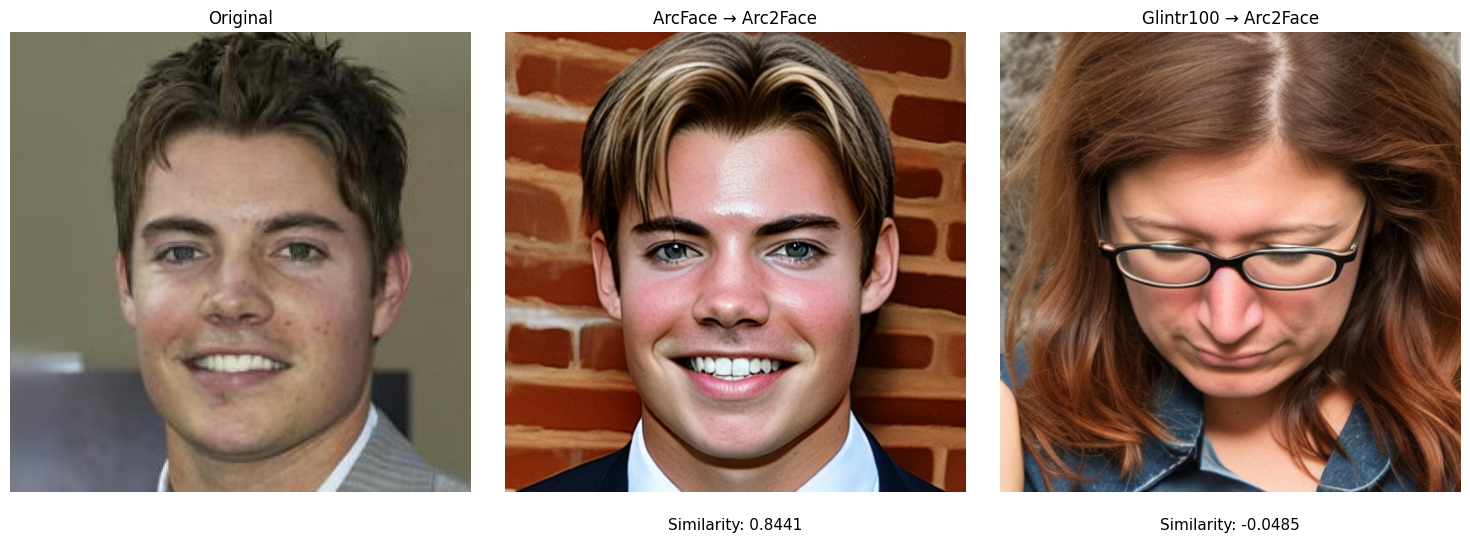

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

# ============================================================
# FILE PATHS
# ============================================================

arcface_path = "arcface_0.png"
glintr_path = "glintr100_0.png"

# ============================================================
# SIMILARITIES
# ============================================================

orig_emb = get_embedding(IMAGE_PATH)

arcface_emb_recon = get_embedding(arcface_path)
glintr_emb_recon = get_embedding(glintr_path)

arcface_score = cosine_similarity(
    orig_emb,
    arcface_emb_recon
)

glintr_score = cosine_similarity(
    orig_emb,
    glintr_emb_recon
)

print(f"ArcFace similarity : {arcface_score:.4f}")
print(f"Glintr similarity  : {glintr_score:.4f}")

# ============================================================
# VISUALIZATION
# ============================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5)
)

# Original
axes[0].imshow(
    Image.open(IMAGE_PATH).convert("RGB")
)
axes[0].set_title("Original")
axes[0].axis("off")

# ArcFace -> Arc2Face
axes[1].imshow(
    Image.open(arcface_path).convert("RGB")
)
axes[1].set_title("ArcFace → Arc2Face")
axes[1].text(
    0.5,
    -0.08,
    f"Similarity: {arcface_score:.4f}",
    ha="center",
    transform=axes[1].transAxes,
    fontsize=11,
)
axes[1].axis("off")

# Glintr -> Arc2Face
axes[2].imshow(
    Image.open(glintr_path).convert("RGB")
)
axes[2].set_title("Glintr100 → Arc2Face")
axes[2].text(
    0.5,
    -0.08,
    f"Similarity: {glintr_score:.4f}",
    ha="center",
    transform=axes[2].transAxes,
    fontsize=11,
)
axes[2].axis("off")

plt.tight_layout()
plt.show()